# **Práctica: EDA de datos crediticios usando GitHub**

Una empresa de servicios financieros quiere analizar información de clientes para comprender qué factores se relacionan con el puntaje crediticio. El dataset contiene variables demográficas, financieras y de comportamiento de pago, como edad, ingresos, cantidad de cuentas bancarias, cantidad de tarjetas de crédito, deuda pendiente, historial crediticio, pagos atrasados y categoría de puntaje crediticio.

El objetivo del trabajo es realizar un análisis exploratorio de datos para identificar patrones relevantes y producir una primera interpretación del problema.

Además, el grupo deberá trabajar usando GitHub como herramienta de colaboración.

Objetivos de la práctica

- crear y organizar un repositorio en git
- subir repositorio a github
- dividir tareas mediante issues;
- trabajar en ramas separadas;
- abrir Pull Requests;
- resolver las consignas
- compartir resultados y dinámica de trabajo

Pasos sugeridos:

1)  crear las carpetas principales del repositorio

2) crear un archivo .gitignore para evitar subir archivos innecesarios

3) crear un README.md con la descripción del proyecto:

      Preguntas para responder:

      - ¿Cuál es el objetivo del análisis?
      - ¿Qué tipo de problema se quiere explorar?
      - ¿Qué información debería encontrar una persona que entra al repositorio por primera vez?

4) Cargar y describir el dataset

5) Seguir los pasos de análisis







# Dataset

| Variable                   | Descripción                                                                                |
| -------------------------- | ------------------------------------------------------------------------------------------ |
| `ID`                       | Identificador único de cada registro del dataset.                                          |
| `Customer_ID`              | Identificador único de cada cliente.                                                       |
| `Month`                    | Período temporal al que corresponde el registro.                                           |
| `Name`                     | Nombre del cliente.                                                                        |
| `Age`                      | Edad del cliente.                                                                          |
| `SSN`                      | Número de seguridad social del cliente.                                                    |
| `Occupation`               | Ocupación o profesión del cliente.                                                         |
| `Annual_Income`            | Ingreso anual del cliente.                                                                 |
| `Monthly_Inhand_Salary`    | Salario mensual disponible del cliente.                                                    |
| `Num_Bank_Accounts`        | Cantidad de cuentas bancarias que posee el cliente.                                        |
| `Num_Credit_Card`          | Cantidad de tarjetas de crédito que posee el cliente.                                      |
| `Interest_Rate`            | Tasa de interés asociada a los préstamos del cliente.                                      |
| `Num_of_Loan`              | Cantidad de préstamos tomados por el cliente.                                              |
| `Type_of_Loan`             | Tipo de préstamo tomado por el cliente.                                                    |
| `Delay_from_due_date`      | Cantidad de días de retraso en el pago respecto de la fecha de vencimiento.                |
| `Num_of_Delayed_Payment`   | Cantidad de pagos realizados con retraso.                                                  |
| `Changed_Credit_Limit`     | Cambios en el límite de crédito del cliente.                                               |
| `Num_Credit_Inquiries`     | Cantidad de consultas de información crediticia realizadas sobre el cliente. |
| `Credit_Mix`               | Composición o combinación de productos crediticios del cliente.                            |
| `Outstanding_Debt`         | Monto de deuda pendiente del cliente.                                                      |
| `Credit_Utilization_Ratio` | Proporción de utilización del crédito disponible.                                          |
| `Credit_History_Age`       | Antigüedad del historial crediticio del cliente.                                           |
| `Payment_of_Min_Amount`    | Indica si el cliente realizó el pago mínimo correspondiente.                               |
| `Total_EMI_per_month`      | Monto total mensual destinado al pago de cuotas o préstamos.                               |
| `Amount_invested_monthly`  | Monto invertido mensualmente por el cliente.                                               |
| `Payment_Behaviour`        | Comportamiento de pago del cliente.                                                        |
| `Monthly_Balance`          | Balance mensual del cliente.                                                       |
| `Credit_Score`             | Categoría de puntaje crediticio del cliente.                                               |


Carga de librerías

In [2]:
# Librerías
import polars as pl
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.lines as lines
import matplotlib.image as mpimg
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

Carga de datos

In [3]:
bank_df = pl.read_csv("C:/Users/sacco/OneDrive/Desktop/An-lisis-exploratorio-cr-ditos/dataset.csv")
bank_df.head()

ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
i64,i64,i64,str,f64,f64,str,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,str,f64,f64,f64,str,f64,f64,str,f64,str
5634,3392,1,"""Aaron Maashoh""",23.0,8.21000265e8,"""Scientist""",19114.12,1824.843333,3.0,4.0,3.0,4.0,"""Auto Loan, Credit-Builder Loan…",3.0,7.0,11.27,4.0,"""Good""",809.98,26.82262,265.0,"""No""",49.574949,21.46538,"""High_spent_Small_value_payment…",312.494089,"""Good"""
5635,3392,2,"""Aaron Maashoh""",23.0,8.21000265e8,"""Scientist""",19114.12,1824.843333,3.0,4.0,3.0,4.0,"""Auto Loan, Credit-Builder Loan…",3.0,4.0,11.27,4.0,"""Good""",809.98,31.94496,266.0,"""No""",49.574949,21.46538,"""Low_spent_Large_value_payments""",284.629162,"""Good"""
5636,3392,3,"""Aaron Maashoh""",23.0,8.21000265e8,"""Scientist""",19114.12,1824.843333,3.0,4.0,3.0,4.0,"""Auto Loan, Credit-Builder Loan…",3.0,7.0,11.27,4.0,"""Good""",809.98,28.609352,267.0,"""No""",49.574949,21.46538,"""Low_spent_Medium_value_payment…",331.209863,"""Good"""
5637,3392,4,"""Aaron Maashoh""",23.0,8.21000265e8,"""Scientist""",19114.12,1824.843333,3.0,4.0,3.0,4.0,"""Auto Loan, Credit-Builder Loan…",5.0,4.0,6.27,4.0,"""Good""",809.98,31.377862,268.0,"""No""",49.574949,21.46538,"""Low_spent_Small_value_payments""",223.45131,"""Good"""
5638,3392,5,"""Aaron Maashoh""",23.0,8.21000265e8,"""Scientist""",19114.12,1824.843333,3.0,4.0,3.0,4.0,"""Auto Loan, Credit-Builder Loan…",6.0,4.0,11.27,4.0,"""Good""",809.98,24.797347,269.0,"""No""",49.574949,21.46538,"""High_spent_Medium_value_paymen…",341.489231,"""Good"""


In [4]:
bank_df.shape

(100000, 28)

In [5]:
bank_df.null_count()

ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [6]:
bank_df.describe()

statistic,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
str,f64,f64,f64,str,f64,f64,str,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,str,f64,f64,f64,str,f64,f64,str,f64,str
"""count""",100000.0,100000.0,100000.0,"""100000""",100000.0,100000.0,"""100000""",100000.0,100000.0,100000.0,100000.0,100000.0,100000.0,"""100000""",100000.0,100000.0,100000.0,100000.0,"""100000""",100000.0,100000.0,100000.0,"""100000""",100000.0,100000.0,"""100000""",100000.0,"""100000"""
"""null_count""",0.0,0.0,0.0,"""0""",0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,"""0""",0.0,0.0,"""0""",0.0,"""0"""
"""mean""",80631.5,25982.66664,4.5,null,33.31634,5.0046e8,null,50505.123449,4197.270835,5.36882,5.53357,14.53208,3.53288,null,21.08141,13.31312,10.470323,5.79825,null,1426.220376,32.285173,221.22046,null,107.699208,55.101315,null,392.697586,null
"""std""",43301.486619,14340.543051,2.291299,null,10.764812,2.9083e8,null,38299.422093,3186.432497,2.593314,2.067098,8.74133,2.446356,null,14.80456,6.237166,6.609481,3.867826,null,1155.129026,5.116875,99.680716,null,132.267056,39.006932,null,201.652719,null
"""min""",5634.0,1006.0,1.0,"""A. Ananthalakshmih""",14.0,81349.0,"""Accountant""",7005.93,303.645417,0.0,0.0,1.0,0.0,"""Auto Loan""",0.0,0.0,0.5,0.0,"""Bad""",0.23,20.0,1.0,"""NM""",0.0,0.0,"""High_spent_Large_value_payment…",0.00776,"""Good"""
"""25%""",43134.0,13665.0,3.0,null,24.0,2.4517755e8,null,19344.27,1626.594167,3.0,4.0,7.0,2.0,null,10.0,9.0,5.38,3.0,null,566.08,28.052568,144.0,null,29.268886,27.960536,null,267.616148,null
"""50%""",80634.0,25780.0,5.0,null,33.0,5.00718498e8,null,37002.58,3095.905,5.0,5.0,13.0,3.0,null,18.0,14.0,9.4,5.0,null,1166.23,32.305891,219.0,null,66.462304,45.156838,null,333.868609,null
"""75%""",118129.0,38384.0,6.0,null,42.0,7.55996164e8,null,71681.4,5957.715,7.0,7.0,20.0,5.0,null,28.0,18.0,14.85,8.0,null,1945.68,36.496612,302.0,null,147.392573,71.288876,null,463.210024,null
"""max""",155629.0,50999.0,8.0,"""yv""",56.0,9.99993421e8,"""Writer""",179987.28,15204.633333,11.0,11.0,34.0,9.0,"""Student Loan, and Student Loan""",62.0,25.0,29.98,17.0,"""Standard""",4998.07,50.0,404.0,"""Yes""",1779.103254,434.191089,"""Low_spent_Small_value_payments""",1183.930696,"""Standard"""


Valores nulos

# Visualizaciones

# Análisis Univariado

A) Distribución del puntaje crediticio

In [7]:
conteo_score = (
    bank_df
    .group_by("Credit_Score")
    .agg(pl.len().alias("cantidad"))
    .sort("cantidad", descending=True)
)

conteo_score

Credit_Score,cantidad
str,u32
"""Standard""",53174
"""Poor""",28998
"""Good""",17828


In [30]:
orden_score = ["Poor", "Standard", "Good"]

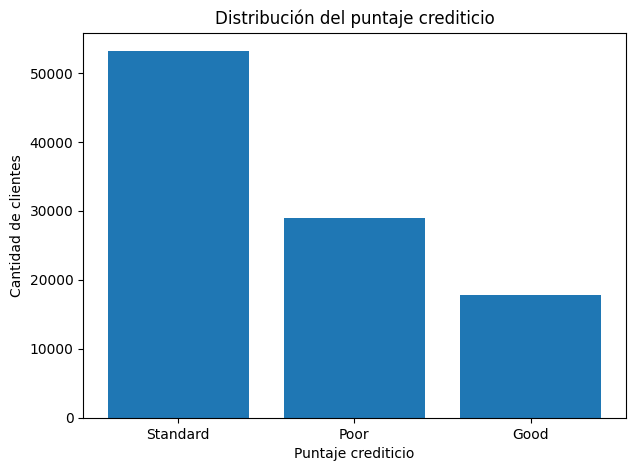

In [8]:
# Gráfico que muestra la distribución del puntaje crediticio

plt.figure(figsize=(7,5))

plt.bar(
    conteo_score["Credit_Score"].to_list(),
    conteo_score["cantidad"].to_list()
)

plt.title("Distribución del puntaje crediticio")
plt.xlabel("Puntaje crediticio")
plt.ylabel("Cantidad de clientes")
plt.show()

B) Distribución por edad

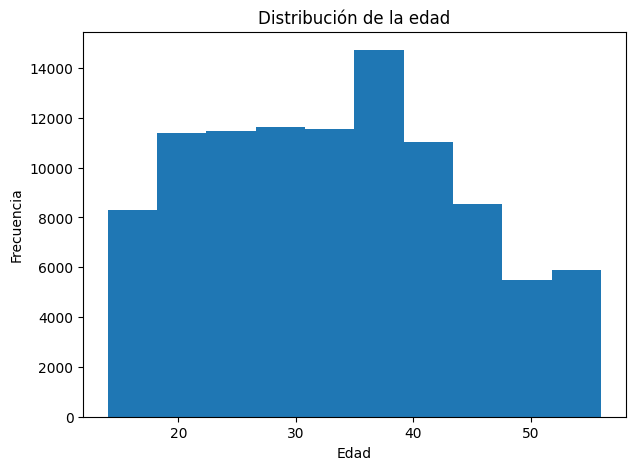

In [9]:
# Histograma de la edad

plt.figure(figsize=(7,5))

plt.hist(
    bank_df["Age"].drop_nulls().to_list()
)

plt.title("Distribución de la edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

C) Distribución por salario (anual y mensual)

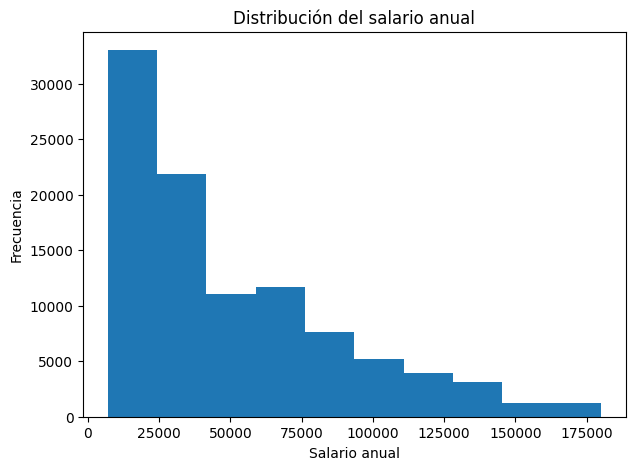

In [10]:
# Distribución por salario anual 

plt.figure(figsize=(7,5))

plt.hist(
    bank_df["Annual_Income"].drop_nulls().to_list()
)

plt.title("Distribución del salario anual")
plt.xlabel("Salario anual")
plt.ylabel("Frecuencia")
plt.show()

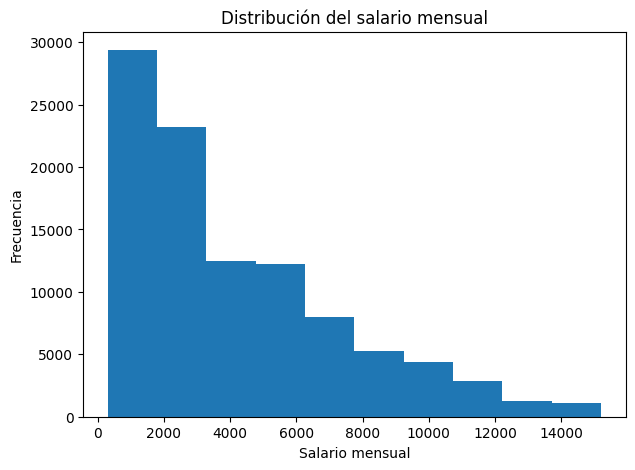

In [11]:
# Distribucion del salario mensual

plt.figure(figsize=(7,5))

plt.hist(
    bank_df["Monthly_Inhand_Salary"].drop_nulls().to_list()
)

plt.title("Distribución del salario mensual")
plt.xlabel("Salario mensual")
plt.ylabel("Frecuencia")
plt.show()

D) Utilización de créditos

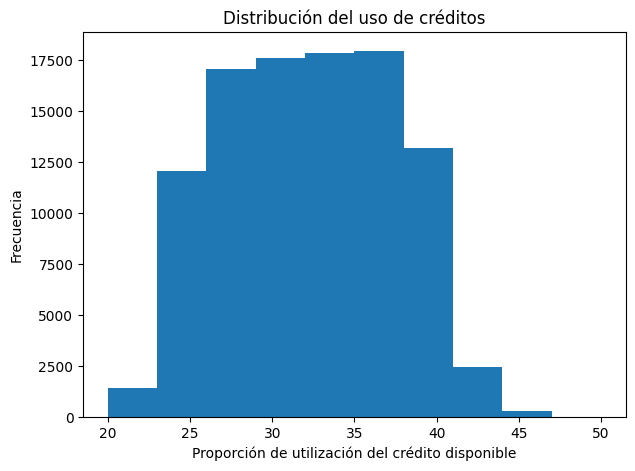

In [12]:
# Distribucion del uso de créditos

plt.figure(figsize=(7,5))

plt.hist(
    bank_df["Credit_Utilization_Ratio"].drop_nulls().to_list()
)

plt.title("Distribución del uso de créditos")
plt.xlabel("Proporción de utilización del crédito disponible")
plt.ylabel("Frecuencia")
plt.show()

E) Distribución tasas de interés

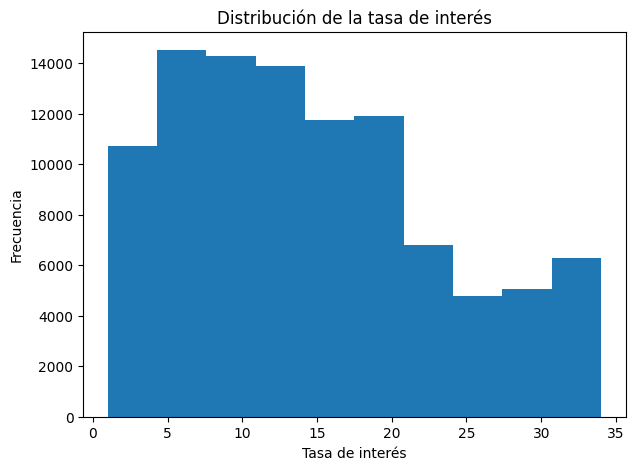

In [14]:
# Distribucion de las tasas de interés 

plt.figure(figsize=(7,5))

plt.hist(
    bank_df["Interest_Rate"].drop_nulls().to_list()
)

plt.title("Distribución de la tasa de interés")
plt.xlabel("Tasa de interés")
plt.ylabel("Frecuencia")
plt.show()

# Análisis Bivariado

A) Ingreso Anual según las distintas ocupaciones

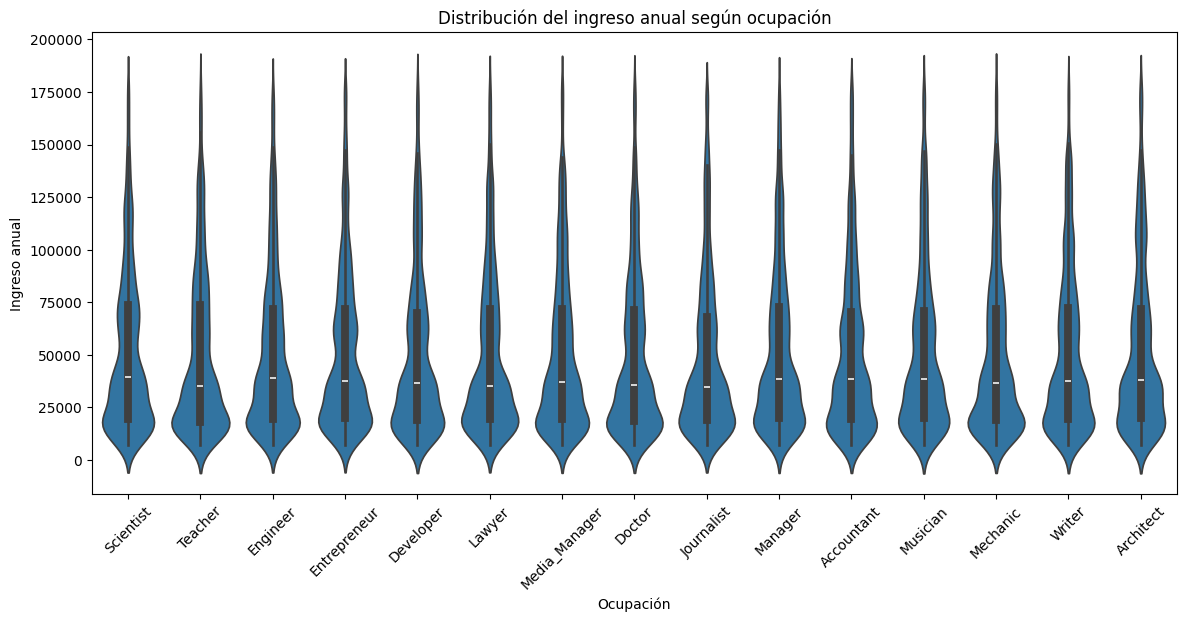

In [17]:
plt.figure(figsize=(14,6))
sns.violinplot(data=bank_df, x="Occupation", y="Annual_Income")
plt.xticks(rotation=45)
plt.title("Distribución del ingreso anual según ocupación")
plt.xlabel("Ocupación")
plt.ylabel("Ingreso anual")
plt.show()

Pareciera que los ingresos anuales se distribuyen de manera similar en cada una de las diferentes ocupaciones. ¿hay ocupaciones con ingresos anuales más altos o más variables que otras? ¿Se observan valores extremos? 

B) Visualizar la relación entre Credit_Utilization_Ratio y Credit_Score para comprender cómo la utilización del crédito impacta en el puntaje crediticio.

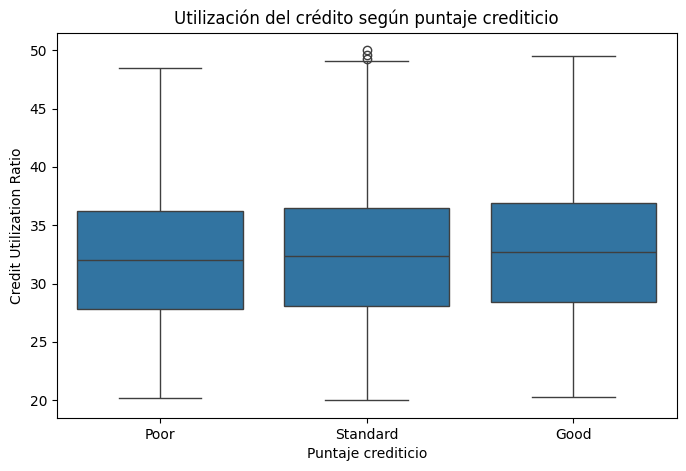

In [31]:
plt.figure(figsize=(8,5))
sns.boxplot(data=bank_df, x="Credit_Score", y="Credit_Utilization_Ratio", order=orden_score)
plt.title("Utilización del crédito según puntaje crediticio")
plt.xlabel("Puntaje crediticio")
plt.ylabel("Credit Utilization Ratio")
plt.show()

C) Visualizar el ingreso anual promedio (Annual_Income) según la ocupación (Occupation).

In [22]:
prom_ingreso = (
    bank_df.groupby("Occupation", as_index=False)["Annual_Income"]
      .mean()
      .sort_values("Annual_Income", ascending=False)
)

plt.figure(figsize=(14,6))
sns.barplot(data=prom_ingreso, x="Occupation", y="Annual_Income")
plt.xticks(rotation=45)
plt.title("Ingreso anual promedio según ocupación")
plt.xlabel("Ocupación")
plt.ylabel("Ingreso anual promedio")
plt.show()



AttributeError: 'DataFrame' object has no attribute 'groupby'

D) Matriz de correlación entre ingresos, préstamos y deudas mediante un mapa de calor.


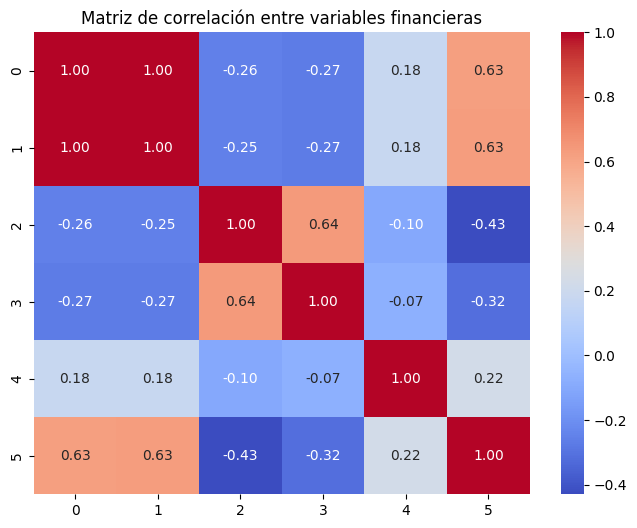

In [24]:
vars_corr = [
    "Annual_Income", "Monthly_Inhand_Salary",
    "Num_of_Loan", "Outstanding_Debt",
    "Credit_Utilization_Ratio", "Monthly_Balance"
]

corr = bank_df[vars_corr].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación entre variables financieras")
plt.show()

E) Visualicen la relación entre la cantidad de préstamos (Num_of_Loan) y el puntaje crediticio (Credit_Score) mediante un gráfico conjunto o una visualización equivalente. El objetivo es observar si la cantidad de préstamos varía según la categoría de puntaje crediticio.

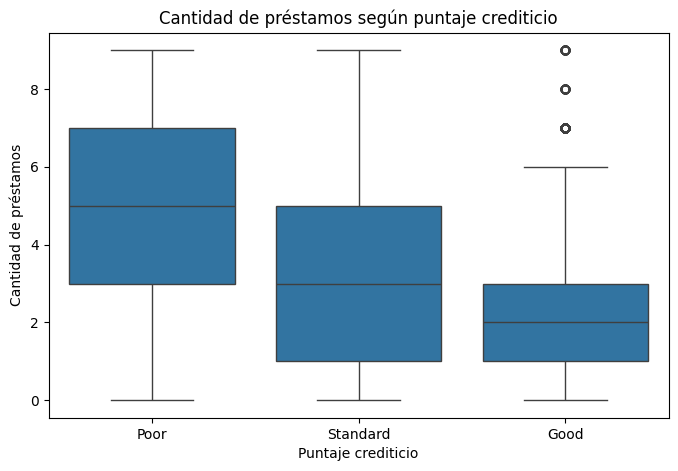

In [32]:
plt.figure(figsize=(8,5))
sns.boxplot(data=bank_df, x="Credit_Score", y="Num_of_Loan", order=orden_score)
plt.title("Cantidad de préstamos según puntaje crediticio")
plt.xlabel("Puntaje crediticio")
plt.ylabel("Cantidad de préstamos")
plt.show()

F) Exploren la relación entre las variables Age, Annual_Income, Monthly_Balance y Outstanding_Debt. Realicen una o más visualizaciones donde los puntos estén diferenciados según la categoría de Credit_Score, para observar si aparece algún patrón entre clientes con puntaje Good, Standard o Poor.

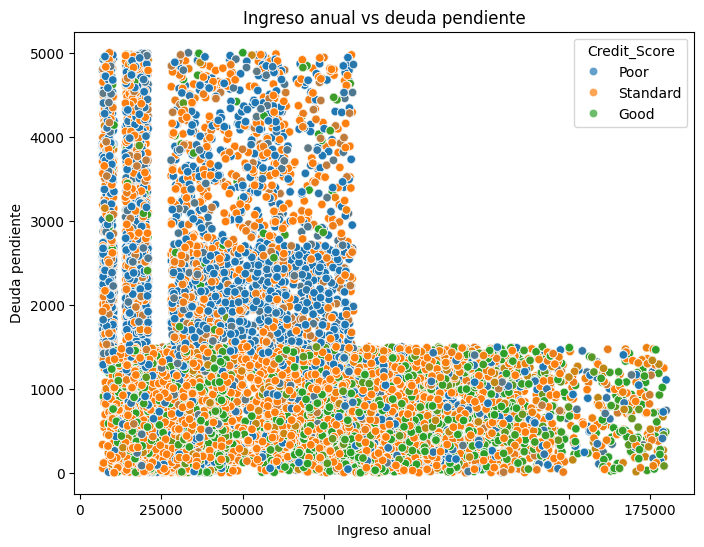

In [33]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=bank_df,
    x="Annual_Income",
    y="Outstanding_Debt",
    hue="Credit_Score",
    hue_order=orden_score,
    alpha=0.7
)
plt.title("Ingreso anual vs deuda pendiente")
plt.xlabel("Ingreso anual")
plt.ylabel("Deuda pendiente")
plt.show()

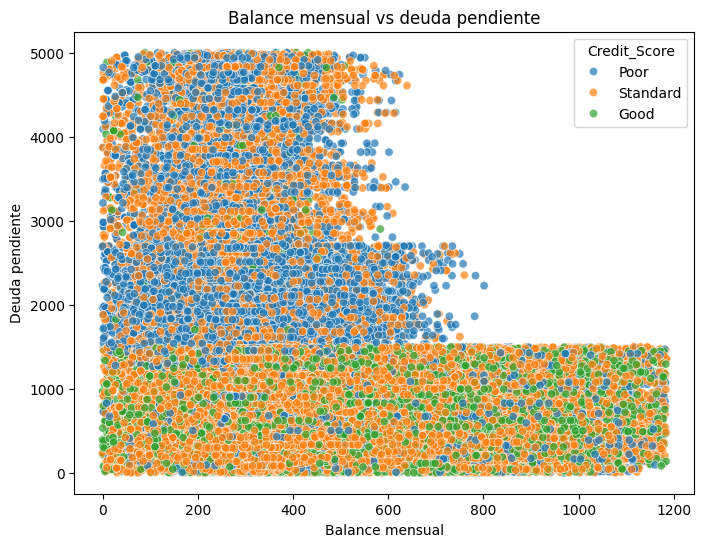

In [34]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=bank_df,
    x="Monthly_Balance",
    y="Outstanding_Debt",
    hue="Credit_Score",
    hue_order=orden_score,
    alpha=0.7
)
plt.title("Balance mensual vs deuda pendiente")
plt.xlabel("Balance mensual")
plt.ylabel("Deuda pendiente")
plt.show()

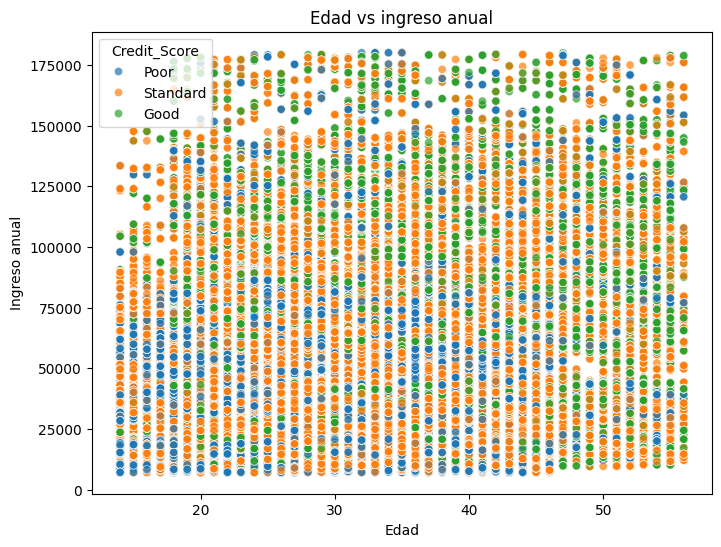

In [35]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=bank_df,
    x="Age",
    y="Annual_Income",
    hue="Credit_Score",
    hue_order=orden_score,
    alpha=0.7
)
plt.title("Edad vs ingreso anual")
plt.xlabel("Edad")
plt.ylabel("Ingreso anual")
plt.show()